# Ma'lumotlar tavsifi

Asl maʼlumotlar toʻplamida professor Hofmann tomonidan tayyorlangan 20 ta toifali/simvolik atributga ega 1000 ta yozuv mavjud. Ushbu toʻplamda har bir yozuv bankdan kredit olgan shaxsni ifodalaydi. Har bir shaxs atributlar toʻplamiga koʻra yaxshi yoki yomon kredit riski sifatida tasniflanadi. Asl maʼlumotlar toʻplamiga havola quyida keltirilgan.

- Yoshi (sonli)
- Jinsi (matn: erkak, ayol)
- Ish turi (sonli: 0 - malakasiz va norezident, 1 - malakasiz va rezident, 2 - malakali, 3 - yuqori malakali)
- Uy-joy (matn: shaxsiy, ijaradagi yoki tekin)
- Jamgʻarma hisobvaraqlari (matn: kam, oʻrtacha, ancha boy, boy)
- Hisob-kitob hisobvaragʻi (sonli, DM - nemis markasida)
- Kredit miqdori (sonli, DMda)
- Muddat (sonli, oyda)
- Maqsad (matn: mashina, mebel/jihozlar, radio/televizor, maishiy texnika, taʼmirlash, taʼlim, biznes, taʼtil/boshqa)
- Risk (maqsadli qiymat - Yaxshi yoki Yomon risk)


### 1. Kerakli kutubxonalarni yuklash

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve
import shap
import joblib


### Ma`lumotlarni yuklash

In [2]:
print("1. Ma'lumotlarni yuklash...")
df =  pd.read_csv('data/german_credit_data.csv', index_col=0)
df.head()

1. Ma'lumotlarni yuklash...


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
print(f"Dataset ma`lumotlari: \n{df.info()}" )
print(70 * '-')
print(f"Bo'sh qiymatlarni tekshirish:\n{df.isnull().sum()} ")

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB
Dataset ma`lumotlari: 
None
----------------------------------------------------------------------
Bo'sh qiymatlarni tekshirish:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0

### 3. EDA (Exploratory Data Analysis) – grafiklar bilan
#### 3.1 Risk sinflari taqsimoti (pie chart)

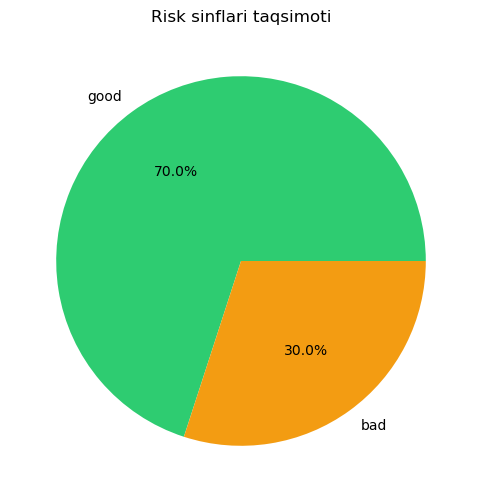

In [4]:
# 3.1 Pie chart
plt.figure(figsize=(6,6))
df['Risk'].value_counts().plot.pie(autopct='%1.1f%%', labels=['good','bad'], colors=['#2ecc71', '#f39c12'])
plt.title('Risk sinflari taqsimoti')
plt.ylabel('')
plt.savefig('risk_pie.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3.2 Sonli xususiyatlar gistogrammasi

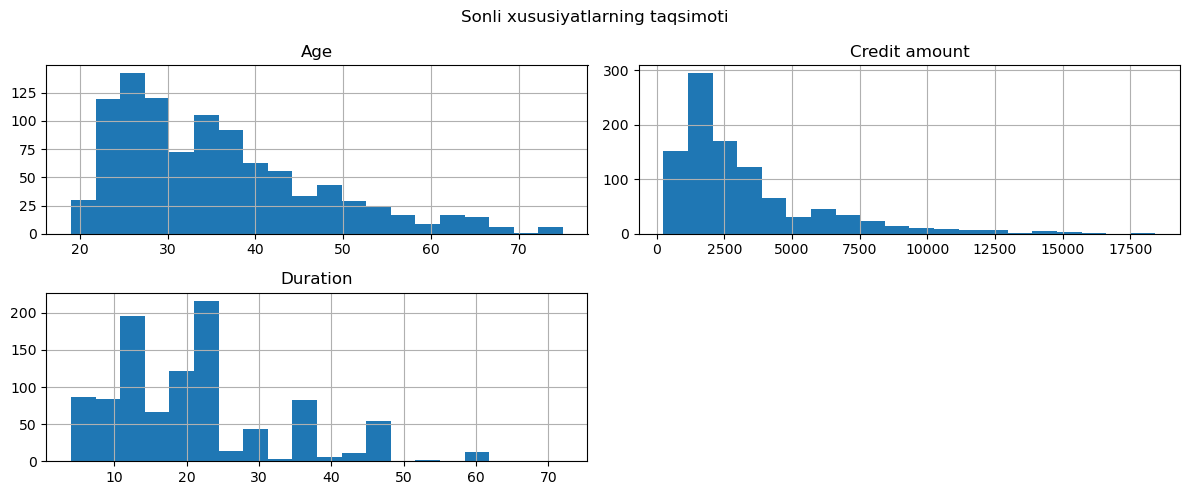

In [5]:
numeric_cols = ['Age', 'Credit amount', 'Duration']
df[numeric_cols].hist(bins=20, figsize=(12,5))
plt.suptitle('Sonli xususiyatlarning taqsimoti')
plt.tight_layout()
plt.savefig('numeric_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3 Kategoriyali o‘zgaruvchilar bo‘yicha risk taqsimoti

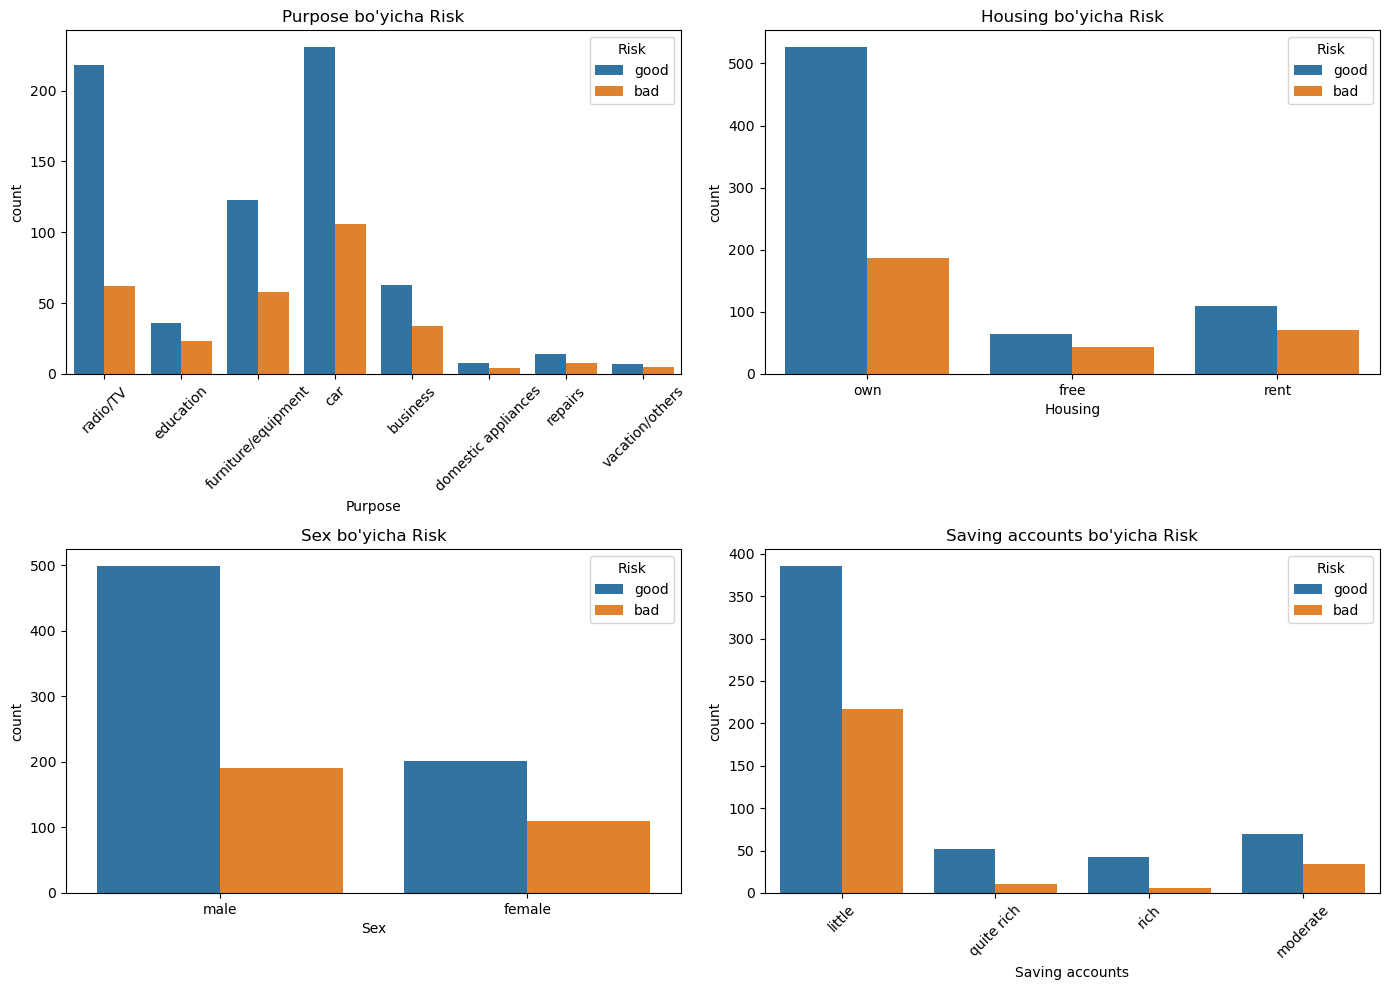

In [6]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(data=df, x='Purpose', hue='Risk', ax=axes[0,0])
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)
axes[0,0].set_title('Purpose bo\'yicha Risk')

sns.countplot(data=df, x='Housing', hue='Risk', ax=axes[0,1])
axes[0,1].set_title('Housing bo\'yicha Risk')

sns.countplot(data=df, x='Sex', hue='Risk', ax=axes[1,0])
axes[1,0].set_title('Sex bo\'yicha Risk')

sns.countplot(data=df, x='Saving accounts', hue='Risk', ax=axes[1,1])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)
axes[1,1].set_title('Saving accounts bo\'yicha Risk')

plt.tight_layout()
plt.savefig('categorical_risk_dist.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.4 Korrelyatsiya matritsasi

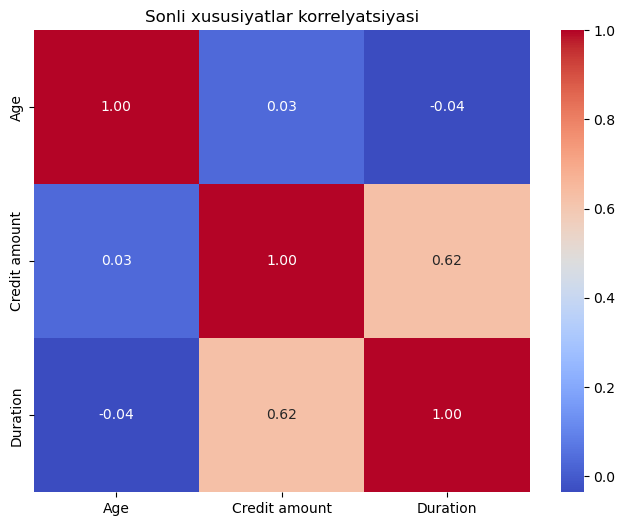

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sonli xususiyatlar korrelyatsiyasi')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Ma'lumotlarni tozalash va xususiyat muhandisligi

In [8]:
# Null qiymatlarni to‘ldirish
df['Saving accounts'].fillna('unknown', inplace=True)
df['Checking account'].fillna('unknown', inplace=True)

# Maqsadli o‘zgaruvchini raqamlarga o‘tkazish
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

# Yangi xususiyatlar
df['Monthly_Payment'] = df['Credit amount'] / df['Duration']
df['Amount_to_Age_Ratio'] = df['Credit amount'] / df['Age']
df['Duration_Group'] = pd.cut(df['Duration'], bins=[0,12,36,100],
                               labels=['Short', 'Medium', 'Long'])

### 5. Preprocessing pipeline (Standartlashtirish + One-hot encoding)

In [9]:
categorical_features = ['Sex', 'Housing', 'Saving accounts',
                        'Checking account', 'Purpose', 'Duration_Group']
numeric_features = ['Age', 'Job', 'Credit amount', 'Duration',
                    'Monthly_Payment', 'Amount_to_Age_Ratio']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

### 6. Train/test split

In [10]:
X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (800, 12), Test size: (200, 12)


### 7. Modellarni giperparametr sozlash (GridSearchCV)

In [11]:
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    )
}

param_grids = {
    'RandomForest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__n_estimators': [100, 200]
    }
}

best_models = {}
for name, model in models.items():
    print(f"\n--- {name} ni sozlash ---")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=5,
                        scoring='roc_auc', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Eng yaxshi parametrlar: {grid.best_params_}")
    print(f"Eng yaxshi CV ROC-AUC: {grid.best_score_:.4f}")


--- RandomForest ni sozlash ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Eng yaxshi parametrlar: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Eng yaxshi CV ROC-AUC: 0.7622

--- XGBoost ni sozlash ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Eng yaxshi parametrlar: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Eng yaxshi CV ROC-AUC: 0.7552


### 8. Threshold optimallashtirish (recall bad >= 0.7)

In [12]:
def find_optimal_threshold(model, X_val, y_val, target_recall_bad=0.7):
    y_proba = model.predict_proba(X_val)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_val, y_proba)
    mask = rec >= target_recall_bad
    if not mask.any():
        best_idx = np.argmax(rec)
    else:
        f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
        f1_masked = f1.copy()
        f1_masked[~mask] = -np.inf
        best_idx = np.argmax(f1_masked)
    return thresh[best_idx] if best_idx < len(thresh) else 0.5

print("\n6. Threshold optimallashtirish (maqsadli recall bad = 0.70)...")
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    opt_thresh = find_optimal_threshold(model, X_test, y_test, target_recall_bad=0.7)
    y_pred_opt = (y_proba >= opt_thresh).astype(int)

    print(f"\n{'-'*50}")
    print(f"Model: {name}")
    print(f"Optimal threshold: {opt_thresh:.3f}")
    print("\n--- Optimallashtirilgan threshold natijalari ---")
    print(classification_report(y_test, y_pred_opt, target_names=['good','bad']))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred_opt))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


6. Threshold optimallashtirish (maqsadli recall bad = 0.70)...

--------------------------------------------------
Model: RandomForest
Optimal threshold: 0.428

--- Optimallashtirilgan threshold natijalari ---
              precision    recall  f1-score   support

        good       0.87      0.63      0.73       140
         bad       0.47      0.78      0.59        60

    accuracy                           0.68       200
   macro avg       0.67      0.71      0.66       200
weighted avg       0.75      0.68      0.69       200

Confusion matrix:
[[88 52]
 [13 47]]
ROC-AUC: 0.7725

--------------------------------------------------
Model: XGBoost
Optimal threshold: 0.530

--- Optimallashtirilgan threshold natijalari ---
              precision    recall  f1-score   support

        good       0.85      0.71      0.78       140
         bad       0.51      0.70      0.59        60

    accuracy                           0.71       200
   macro avg       0.68      0.71      0.68      

### 9. SHAP tahlili (xususiyat ahamiyati)

 SHAP yordamida xususiyat ahamiyatini tahlil qilish
Xususiyatlar soni: 25
X_test_trans shakli: (200, 25)
type(shap_values): <class 'numpy.ndarray'>
shap_values.shape: (200, 25, 2)
shap_values_bad boshlang'ich shakli: (200, 25)
shap_values_bad tuzatilgan shakli: (200, 25)


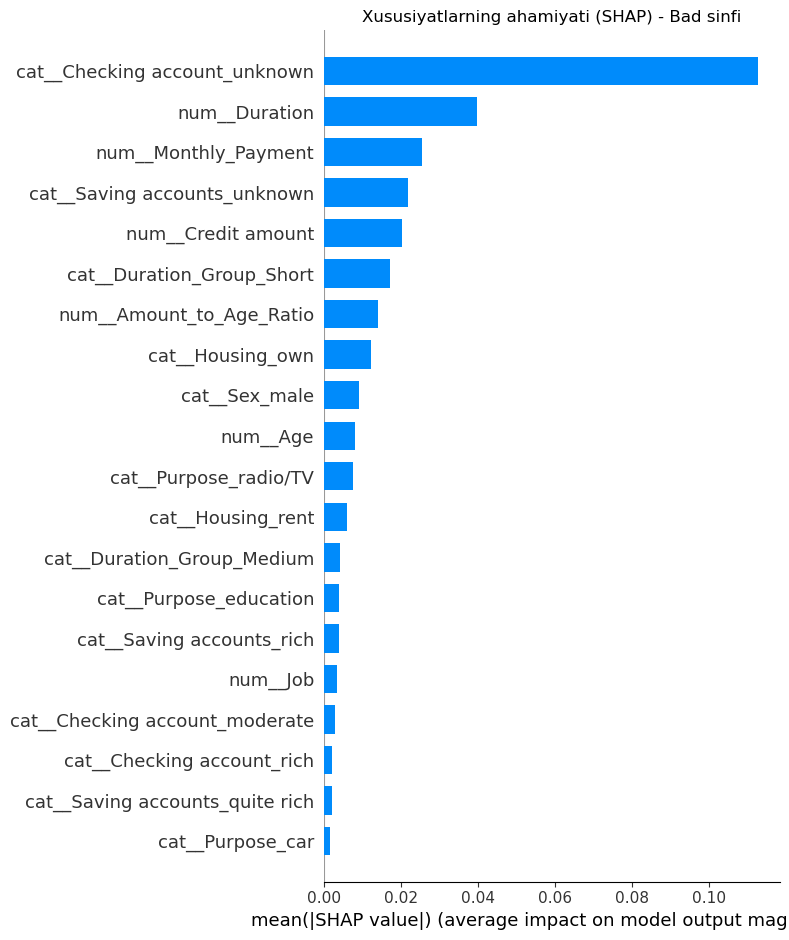

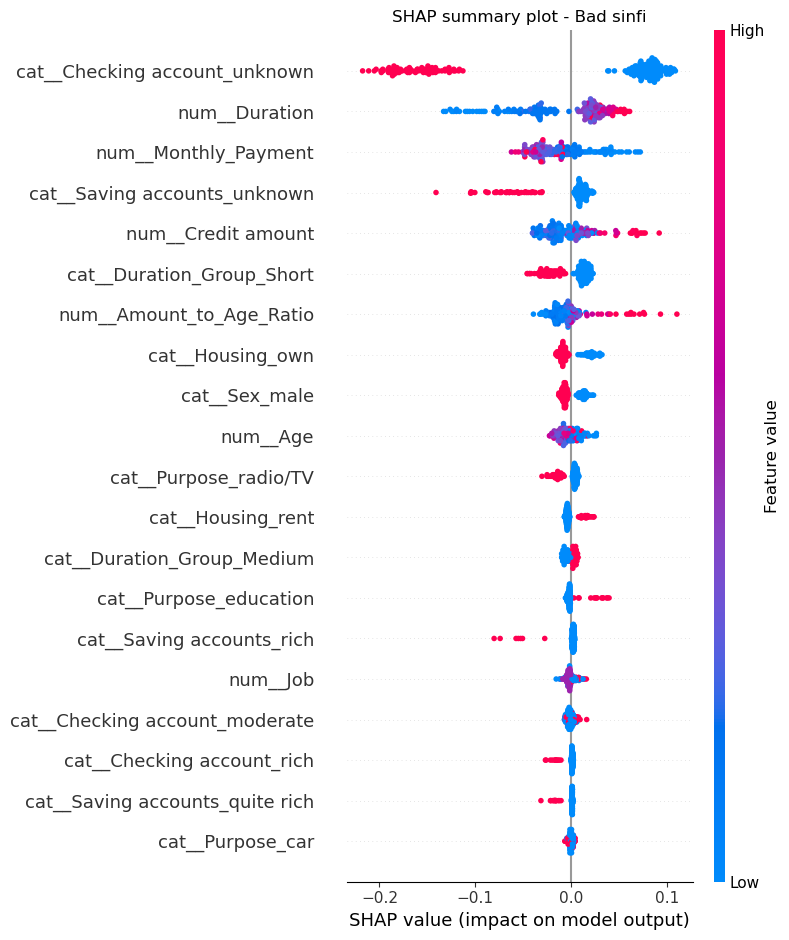

In [13]:
print(" SHAP yordamida xususiyat ahamiyatini tahlil qilish")

# Preprocessingni alohida o‘rgatamiz
preprocessor.fit(X_train)
X_test_trans = preprocessor.transform(X_test)

# Sparse matrixni dense arrayga o‘tkazamiz (agar kerak bo‘lsa)
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()
    print("X_test_trans dense arrayga o'tkazildi")

feature_names = preprocessor.get_feature_names_out()
print(f"Xususiyatlar soni: {len(feature_names)}")
print(f"X_test_trans shakli: {X_test_trans.shape}")

# RandomForest modelini olish
rf_best = best_models['RandomForest'].named_steps['classifier']

# SHAP explainer
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_trans)

# SHAP qiymatlarining tuzilishini tekshirish
print(f"type(shap_values): {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List uzunligi: {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"shap_values[{i}].shape: {sv.shape}")
else:
    print(f"shap_values.shape: {shap_values.shape}")

# Ikkinchi sinf (bad) uchun SHAP qiymatlarini olish
if isinstance(shap_values, list):
    shap_values_bad = shap_values[1]
else:
    # 3D array: (n_samples, n_features, n_classes) bo'lishi mumkin
    shap_values_bad = shap_values[:, :, 1]

print(f"shap_values_bad boshlang'ich shakli: {shap_values_bad.shape}")

# Shaklni to'g'rilash (agar kerak bo'lsa)
if len(shap_values_bad.shape) == 2:
    # Agar (n_features, n_samples) bo'lsa, transpozitsiya qilamiz
    if shap_values_bad.shape[0] == X_test_trans.shape[1] and shap_values_bad.shape[1] == X_test_trans.shape[0]:
        shap_values_bad = shap_values_bad.T
        print("Transpozitsiya qilindi")
    # Agar (n_samples, n_features) bo'lsa, hech narsa qilmaymiz
    elif shap_values_bad.shape[0] == X_test_trans.shape[0] and shap_values_bad.shape[1] == X_test_trans.shape[1]:
        pass
    else:
        raise ValueError(f"Shapes mismatch: {shap_values_bad.shape} vs {X_test_trans.shape}")

print(f"shap_values_bad tuzatilgan shakli: {shap_values_bad.shape}")

# Bar chart - muhim xususiyatlar
plt.figure()
shap.summary_plot(shap_values_bad, X_test_trans, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title("Xususiyatlarning ahamiyati (SHAP) - Bad sinfi")
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Dot summary plot - batafsil tahlil
plt.figure()
shap.summary_plot(shap_values_bad, X_test_trans, feature_names=feature_names,
                  show=False)
plt.title("SHAP summary plot - Bad sinfi")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Modelni saqlash

In [14]:
print("\n8. Eng yaxshi modelni saqlash:")
# Modelni saqlash
best_rf_pipeline = best_models['RandomForest']
#joblib.dump(best_rf_pipeline, 'models/credit_risk_model_rf_pipeline.pkl')

# Preprocessorni saqlash
#joblib.dump(preprocessor, 'models/preprocessor.pkl')
#print("Preprocessor 'preprocessor.pkl' fayliga saqlandi.")



8. Eng yaxshi modelni saqlash:


In [15]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_rf_pipeline, 'models/credit_risk_model_rf_pipeline.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')

['models/preprocessor.pkl']